<a href="https://colab.research.google.com/github/JoannaAch/DataScience_2026/blob/main/AlphaGenome_tutorial_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title Install AlphaGenome

# @markdown Run this cell to install AlphaGenome.
from IPython.display import clear_output
! pip install alphagenome
clear_output()

In [2]:
from alphagenome import colab_utils
from alphagenome.data import gene_annotation, genome, track_data, transcript
from alphagenome.models import dna_client
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
dna_model = dna_client.create(colab_utils.get_api_key())

In [17]:
# Load metadata objects for human.
output_metadata = dna_model.output_metadata(
    organism=dna_client.Organism.HOMO_SAPIENS
)
output_metadata

OutputMetadata(atac=                        name strand Assay title  ontology_curie  \
0        CL:0000084 ATAC-seq      .    ATAC-seq      CL:0000084   
1        CL:0000100 ATAC-seq      .    ATAC-seq      CL:0000100   
2        CL:0000236 ATAC-seq      .    ATAC-seq      CL:0000236   
3        CL:0000623 ATAC-seq      .    ATAC-seq      CL:0000623   
4        CL:0000624 ATAC-seq      .    ATAC-seq      CL:0000624   
..                       ...    ...         ...             ...   
162  UBERON:0008953 ATAC-seq      .    ATAC-seq  UBERON:0008953   
163  UBERON:0008971 ATAC-seq      .    ATAC-seq  UBERON:0008971   
164  UBERON:0010414 ATAC-seq      .    ATAC-seq  UBERON:0010414   
165  UBERON:0011907 ATAC-seq      .    ATAC-seq  UBERON:0011907   
166  UBERON:0015143 ATAC-seq      .    ATAC-seq  UBERON:0015143   

                      biosample_name                 biosample_type  \
0                             T-cell                   primary_cell   
1                       motor neu

In [5]:
# Load gene annotations (from GENCODE).
gtf = pd.read_feather(
    'https://storage.googleapis.com/alphagenome/reference/gencode/'
    'hg38/gencode.v46.annotation.gtf.gz.feather'
)

# Filter to protein-coding genes and highly supported transcripts.
gtf_transcript = gene_annotation.filter_transcript_support_level(
    gene_annotation.filter_protein_coding(gtf), ['1']
)

# Extractor for identifying transcripts in a region.
transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

# Also define an extractor that fetches only the longest transcript per gene.
gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
    gtf_transcript
)
longest_transcript_extractor = transcript.TranscriptExtractor(
    gtf_longest_transcript
)

Visualise gene expression - RNA-seq and CAGE

In [10]:
# @title Visualise gene expression - RNA-seq and CAGE
# Define interval to make predictions.
# Note that the interval width must be one of the supported sequence lengths.
interval = genome.Interval('chr19', 50_150_000, 51_150_000).resize(
    dna_client.SEQUENCE_LENGTH_1MB
)

# Define the tissues/cell-types to predict expression for.
ontology_terms = [
    'UBERON:0002367',  # Prostate gland
]

# Make predictions.
output = dna_model.predict_interval(
    interval=interval,
    requested_outputs={
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.CAGE,
    },
    ontology_terms=ontology_terms,
)

# Extract the longest transcripts per gene for this interval.
longest_transcripts = longest_transcript_extractor.extract(interval)

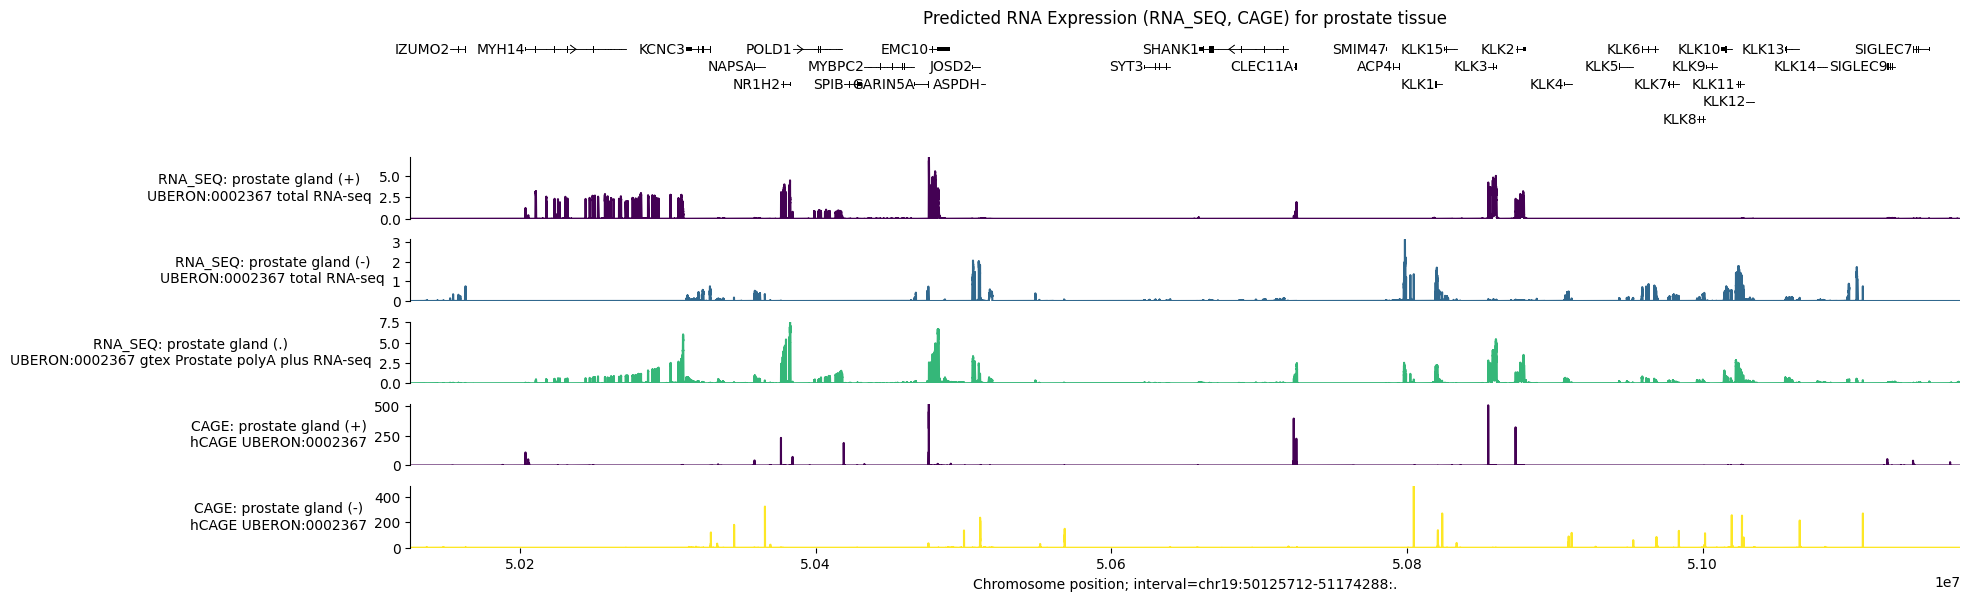

In [11]:
#  @title Build plot.
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),
        plot_components.Tracks(
            tdata=output.rna_seq,
            ylabel_template='RNA_SEQ: {biosample_name} ({strand})\n{name}',
        ),
        plot_components.Tracks(
            tdata=output.cage,
            ylabel_template='CAGE: {biosample_name} ({strand})\n{name}',
        ),
    ],
    interval=interval,
    title='Predicted RNA Expression (RNA_SEQ, CAGE) for prostate tissue',
)

Chromatin accessibility from DNAseq-seq and ATAC-seq

In [12]:
#  @title Chromatin Accessibility - DNAseq-seq and ATAC-seq
#Make predictions.
output = dna_model.predict_interval(
    interval,
    requested_outputs={
        dna_client.OutputType.DNASE,
        dna_client.OutputType.ATAC,
    },
    ontology_terms=ontology_terms,
)

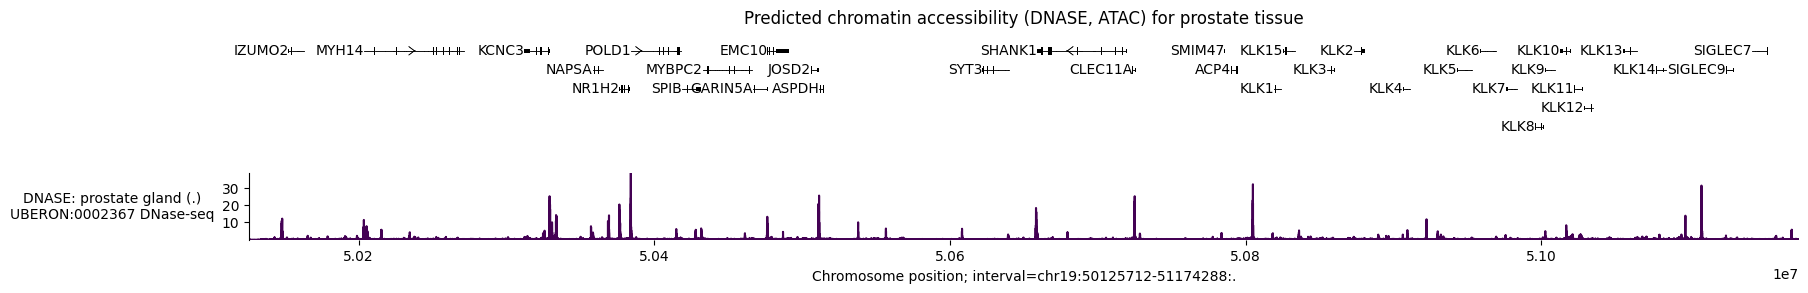

In [13]:
#  @title Build plot.
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),
        plot_components.Tracks(
            tdata=output.dnase,
            ylabel_template='DNASE: {biosample_name} ({strand})\n{name}',
        ),
        plot_components.Tracks(
            tdata=output.atac,
            ylabel_template='ATAC: {biosample_name} ({strand})\n{name}',
        ),
    ],
    interval=interval,
    title='Predicted chromatin accessibility (DNASE, ATAC) for prostate tissue',
)

ChIP - Transcription factor binding:     
"EFO:0001663",  # prostate cancer
"EFO:0000673",  # prostate adenocarcinoma

In [24]:
# @title ChIP-seq transcriptin factor (TF) binding
ontology_terms = [
    'UBERON:0002367',  # Prostate gland
    "EFO:0005726", # prostate cancer LNCaP
    "EFO:00002074" # prostate cancer PC3
]

output = dna_model.predict_interval(
    interval=interval,
    requested_outputs={dna_client.OutputType.CHIP_TF},
    ontology_terms=ontology_terms,
)

In [25]:
output_chip_tf = output.chip_tf.filter_tracks(
    (output.chip_tf.metadata['ontology_curie'].isin(ontology_terms)).values
)
len(output_chip_tf.metadata)

4

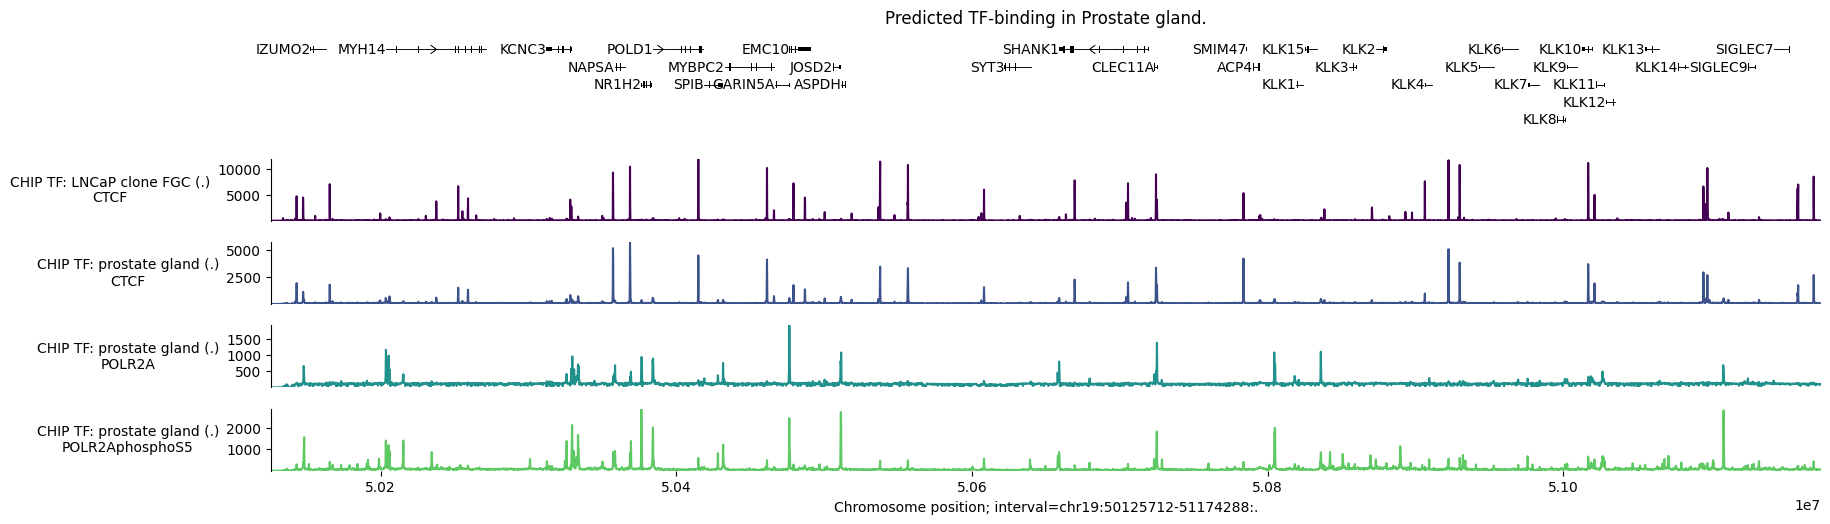

In [26]:
#  @title Build plot.
plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),
        plot_components.Tracks(
            tdata=output_chip_tf,
            ylabel_template=
                'CHIP TF: {biosample_name} ({strand})\n{transcription_factor}'
            ),
    ],
    interval=interval,
    title='Predicted TF-binding in Prostate gland.'
)
plt.show()

3D contact maps

In [27]:
# @title 3D Chromatin contacts from Hi-C data
ontology_terms = [
    "EFO:0005726",  # LNCaP prostate cancer cell line.
]

output = dna_model.predict_interval(
    interval=interval,
    requested_outputs={dna_client.OutputType.CONTACT_MAPS},
    ontology_terms=ontology_terms,
)

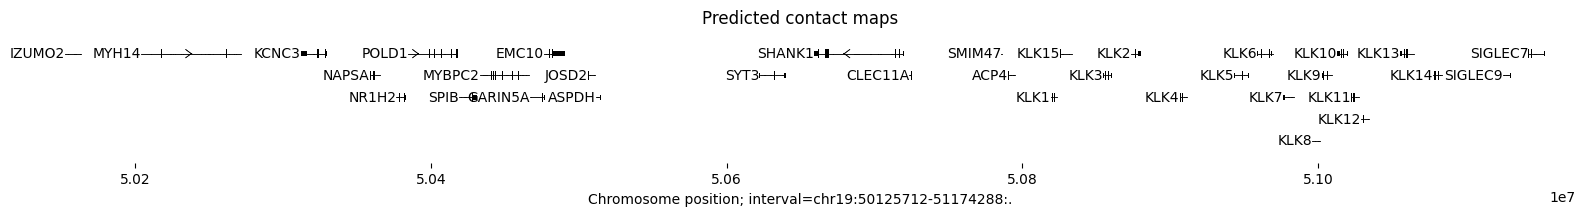

In [28]:
# @title Build plot
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),
        plot_components.ContactMaps(
            tdata=output.contact_maps,
            ylabel_template='{biosample_name}\n{name}',
            cmap='autumn_r',
            vmax=1.0,
        ),
    ],
    interval=interval,
    title='Predicted contact maps',
)
plt.show()

In [29]:
#  @title Plot 3D chromatin contacts based on a different dataset
ontology_terms = [
    'EFO:0002824',  # HCT116 colon carcinoma cell line.
]

output = dna_model.predict_interval(
    interval=interval,
    requested_outputs={dna_client.OutputType.CONTACT_MAPS},
    ontology_terms=ontology_terms,
)

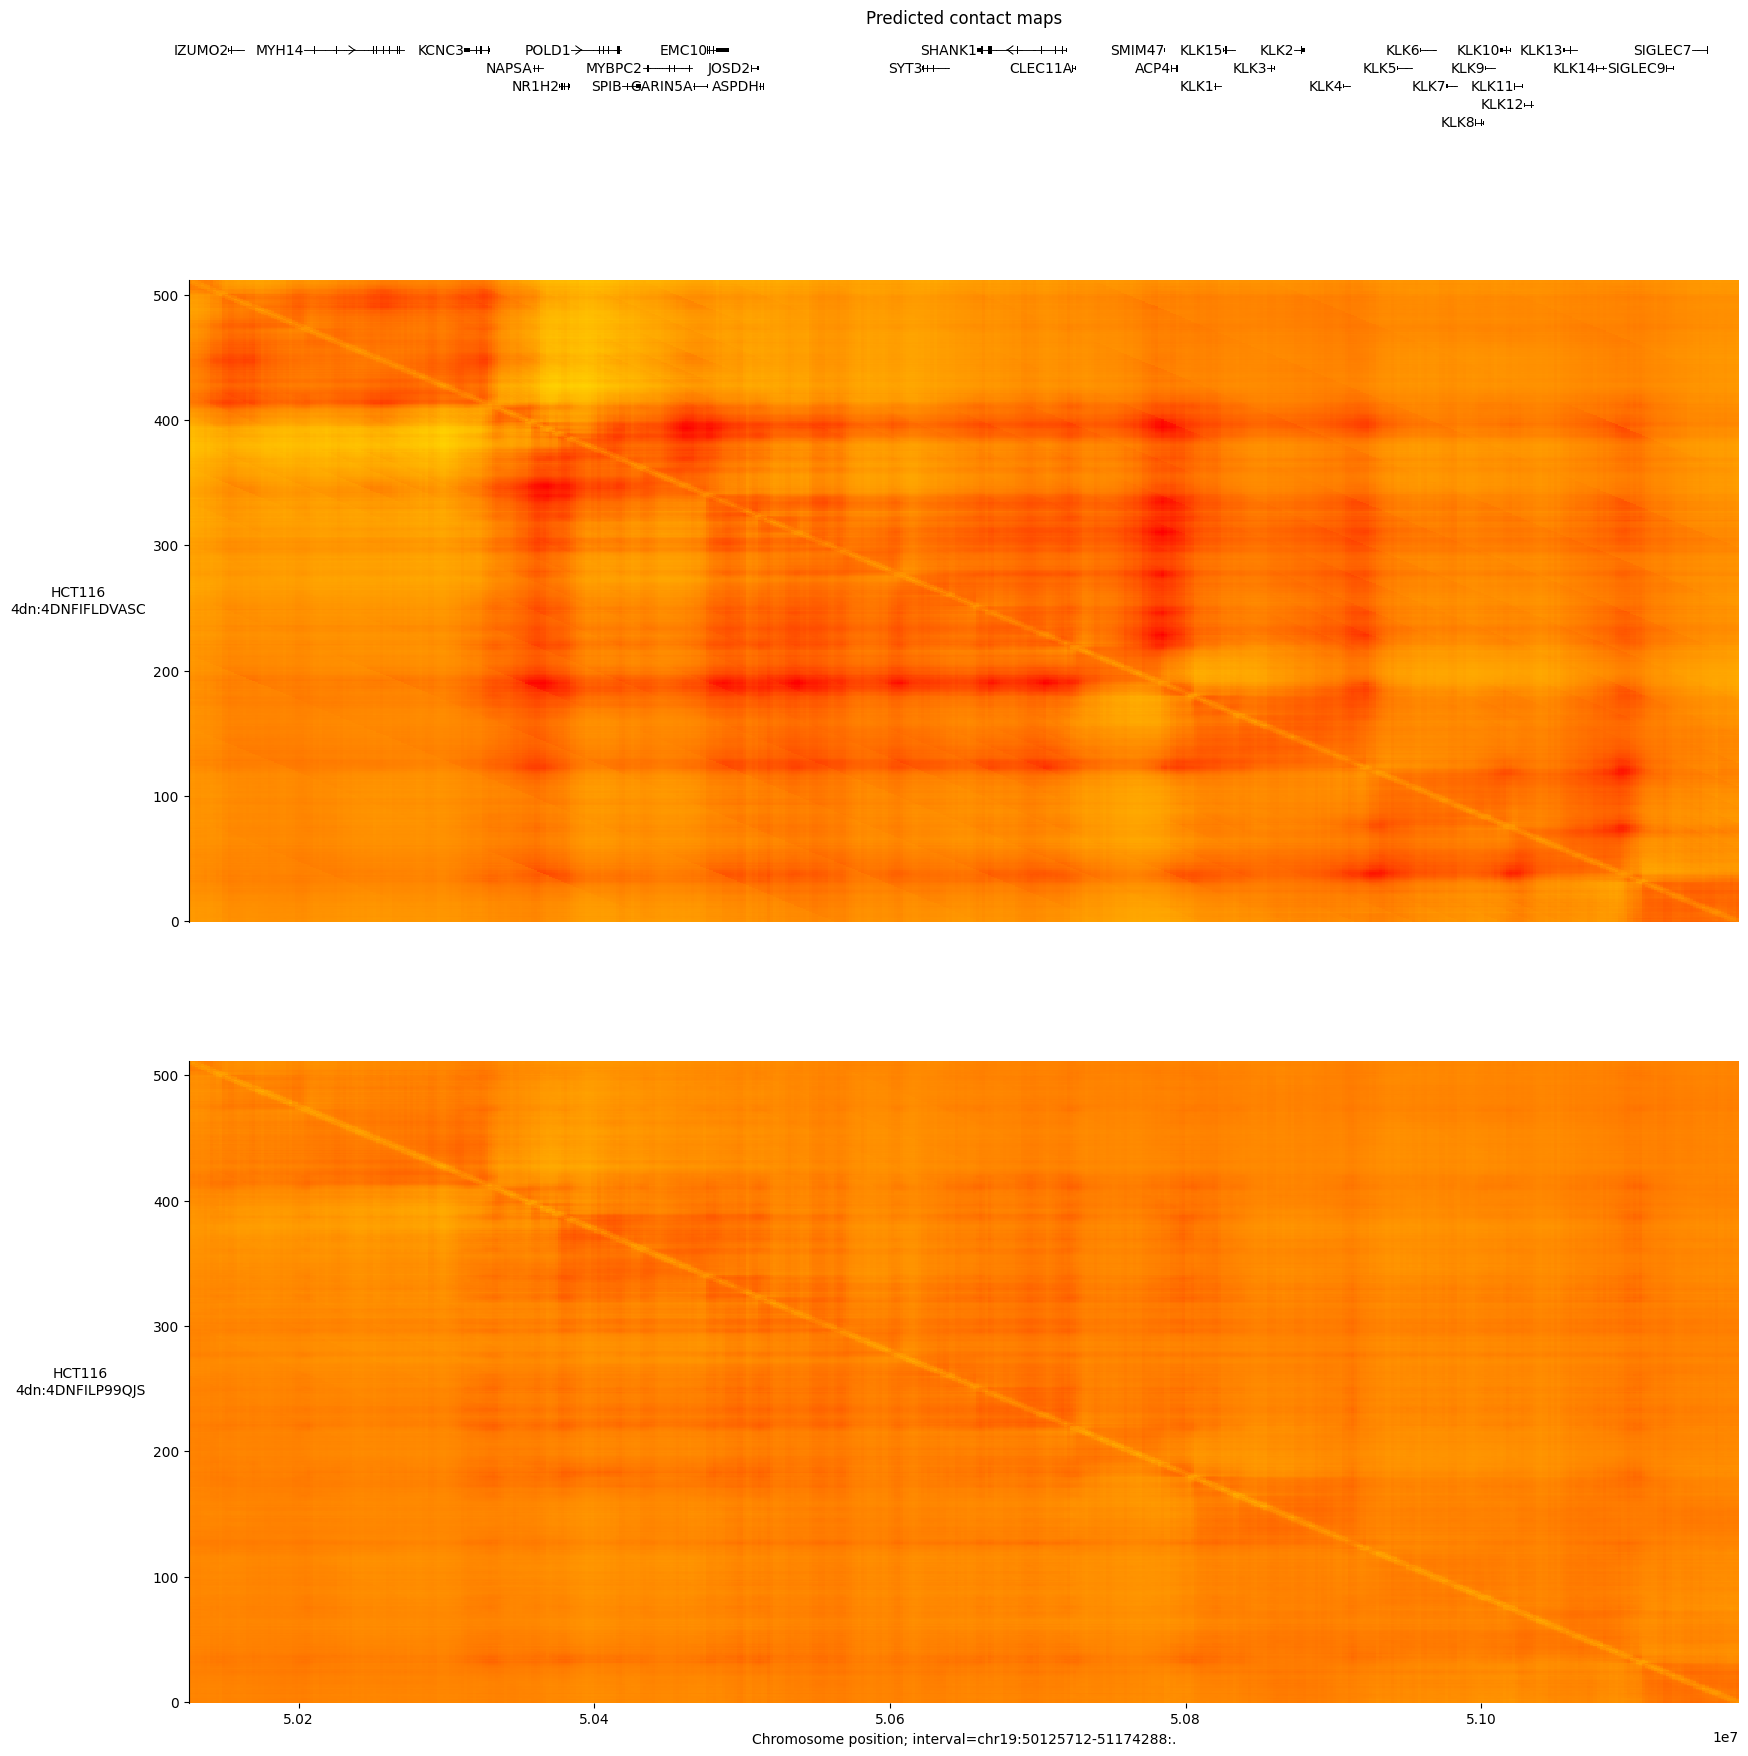

In [30]:
# @title Build plot
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),
        plot_components.ContactMaps(
            tdata=output.contact_maps,
            ylabel_template='{biosample_name}\n{name}',
            cmap='autumn_r',
            vmax=1.0,
        ),
    ],
    interval=interval,
    title='Predicted contact maps',
)
plt.show()